# Support Vector Machine (SVM) for Facial Emotion Recognition

## Overview
This notebook implements a Support Vector Machine classifier for emotion recognition using preprocessed LBP (Local Binary Pattern) features.

## Pipeline
1. **Load preprocessed LBP features** - Already extracted and normalized histogram features
2. **PCA dimensionality reduction** - Retain 95% of variance (recommended default)
3. **Baseline SVM** - Train with default hyperparameters (C=1.0, RBF kernel)
4. **Hyperparameter tuning** - Grid search over kernel, C, and gamma using validation set
5. **Evaluation** - Compare baseline vs tuned on test set

## Key Notes
- **No StandardScaler needed**: LBP histogram features are already normalized during preprocessing
- **PCA n_components=0.95**: Retains 95% of variance (good default per preprocessing example)
- **Train/Val/Test split**: Already provided by `load_grouped_splits()`
- **Final training**: After tuning, model is refit on train+val for better generalization
- **SVM is sensitive to hyperparameters**: Tuning kernel, C, and gamma is critical for good performance

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from train_test_split import load_grouped_splits

from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set random seed for reproducibility
np.random.seed(42)

In [19]:
# Load preprocessed LBP features with train/val/test splits
# Note: Features are already normalized LBP histograms, no StandardScaler needed
X_train, y_train, X_val, y_val, X_test, y_test, classes = load_grouped_splits()

print("Loaded preprocessed LBP data:")
print(f"  - Training samples: {X_train.shape[0]}")
print(f"  - Validation samples: {X_val.shape[0]}")
print(f"  - Test samples: {X_test.shape[0]}")
print(f"  - Feature dimension: {X_train.shape[1]}")
print(f"  - Number of classes: {len(classes)}")
print(f"  - Class names: {classes}")

# Baseline pipeline (no tuning): PCA -> SVM (default C=1.0, RBF kernel)
# Note: No StandardScaler - LBP histograms are already normalized
baseline_pipe = Pipeline([
    ("pca", PCA(n_components=0.95)),  # Retain 95% variance (recommended default)
    ("svc", SVC(kernel='rbf', C=1.0, random_state=42))
])

baseline_pipe.fit(X_train, y_train)

# Check actual PCA components used
n_components_used = baseline_pipe.named_steps["pca"].n_components_
print(f"\nPCA reduced features from {X_train.shape[1]} to {n_components_used} components")

y_val_pred_baseline = baseline_pipe.predict(X_val)
y_test_pred_baseline = baseline_pipe.predict(X_test)

print("\nBaseline (default SVM: C=1.0, kernel='rbf', gamma='scale'):")
print(f"  Val accuracy:  {accuracy_score(y_val, y_val_pred_baseline)*100:.2f}%")
print(f"  Test accuracy: {accuracy_score(y_test, y_test_pred_baseline)*100:.2f}%")
print("\nTest classification report:")
print(classification_report(y_test, y_test_pred_baseline, target_names=classes))

Train size: 96
Validation size: 24
Test size: 32
Loaded preprocessed LBP data:
  - Training samples: 96
  - Validation samples: 24
  - Test samples: 32
  - Feature dimension: 16384
  - Number of classes: 8
  - Class names: ['Anger' 'Contempt' 'Disgust' 'Fear' 'Happy' 'Neutral' 'Sad' 'Surprised']

PCA reduced features from 16384 to 62 components

Baseline (default SVM: C=1.0, kernel='rbf', gamma='scale'):
  Val accuracy:  33.33%
  Test accuracy: 34.38%

Test classification report:
              precision    recall  f1-score   support

       Anger       0.33      0.50      0.40         4
    Contempt       0.00      0.00      0.00         4
     Disgust       0.40      0.50      0.44         4
        Fear       0.24      1.00      0.38         4
       Happy       1.00      0.50      0.67         4
     Neutral       0.50      0.25      0.33         4
         Sad       0.00      0.00      0.00         4
   Surprised       0.00      0.00      0.00         4

    accuracy               

c:\Users\Lars Magne\Informatikk\Andre_ar\Datadrevet Programvare\IT3212\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lars Magne\Informatikk\Andre_ar\Datadrevet Programvare\IT3212\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lars Magne\Informatikk\Andre_ar\Datadrevet Programvare\IT3212\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `

In [20]:
# Hyperparameter tuning with 5-fold cross-validation on training data only
from sklearn.model_selection import StratifiedKFold

print(f"Training set for GridSearch: {len(X_train)} samples")
print(f"Using 5-fold stratified cross-validation")

# SVM pipeline + grid
svm_pipe = Pipeline([
    ("pca", PCA(n_components=0.90)),
    ("svc", SVC(random_state=42))
])

# Comprehensive grid: kernel, C, and gamma
# Note: gamma only used for RBF kernel, linear kernel ignores it
svm_param_grid = [
    # RBF kernel: tune C and gamma
    {
        "svc__kernel": ["rbf"],
        "svc__C": np.logspace(-2, 3, 6),  # [0.01, 0.1, 1, 10, 100, 1000]
        "svc__gamma": ["scale", "auto", 0.001, 0.01, 0.1]
    },
    # Linear kernel: tune C only (gamma ignored)
    {
        "svc__kernel": ["linear"],
        "svc__C": np.logspace(-2, 3, 6) 
    }
]

# Calculate total fits more accurately
rbf_combos = 1 * 6 * 5  # kernel × C × gamma
linear_combos = 1 * 6    # kernel × C
total_combos = rbf_combos + linear_combos
total_fits = total_combos * 5
print(f"\nSearching {total_combos} hyperparameter combinations with 5-fold CV...")
print(f"  - RBF kernel: {rbf_combos} combinations")
print(f"  - Linear kernel: {linear_combos} combinations")
print(f"Total fits: {total_fits}")
print("(This may take a few minutes)\n")

# Use StratifiedKFold for 5-fold CV on training data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
svm_gs = GridSearchCV(svm_pipe, svm_param_grid, cv=cv, scoring="accuracy", n_jobs=-1, refit=True, verbose=2)
svm_gs.fit(X_train, y_train)  # Tune on training data only using 5-fold CV

print("\nTuned model (GridSearchCV with 5-fold CV):")
print(f"  Best kernel: {svm_gs.best_params_['svc__kernel']}")
print(f"  Best C: {svm_gs.best_params_['svc__C']}")
print(f"  Best gamma: {svm_gs.best_params_['svc__gamma']}")
print(f"  Best CV score (mean of 5 folds): {svm_gs.best_score_*100:.2f}%")

# Check actual PCA components used
best_svm = svm_gs.best_estimator_
n_components_tuned = best_svm.named_steps["pca"].n_components_
print(f"  PCA components: {n_components_tuned}")

# Evaluate on validation set
y_val_pred_tuned = best_svm.predict(X_val)
val_acc_tuned = accuracy_score(y_val, y_val_pred_tuned)
print(f"\nValidation accuracy: {val_acc_tuned*100:.2f}%")

# Now retrain on train+val for final model
print("\nRetraining on combined train+val for final model...")
X_final = np.vstack([X_train, X_val])
y_final = np.hstack([y_train, y_val])

# Extract best SVC params (remove svc__ prefix)
best_svc_params = {k.replace('svc__', ''): v for k, v in svm_gs.best_params_.items() if k.startswith('svc__')}

final_pipe = Pipeline([
    ("pca", PCA(n_components=0.95)),
    ("svc", SVC(**best_svc_params, random_state=42))
])
final_pipe.fit(X_final, y_final)

# Final evaluation on test set
y_test_pred_tuned = final_pipe.predict(X_test)
test_acc_tuned = accuracy_score(y_test, y_test_pred_tuned)

print(f"\nFinal test accuracy (trained on train+val): {test_acc_tuned*100:.2f}%")
print("\nTest classification report:")
print(classification_report(y_test, y_test_pred_tuned, target_names=classes))

# Update best_svm to final model for visualization cells
best_svm = final_pipe

Training set for GridSearch: 96 samples
Using 5-fold stratified cross-validation

Searching 36 hyperparameter combinations with 5-fold CV...
  - RBF kernel: 30 combinations
  - Linear kernel: 6 combinations
Total fits: 180
(This may take a few minutes)

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Tuned model (GridSearchCV with 5-fold CV):
  Best kernel: rbf
  Best C: 1000.0
  Best gamma: 0.1
  Best CV score (mean of 5 folds): 12.42%
  PCA components: 43

Validation accuracy: 37.50%

Retraining on combined train+val for final model...

Tuned model (GridSearchCV with 5-fold CV):
  Best kernel: rbf
  Best C: 1000.0
  Best gamma: 0.1
  Best CV score (mean of 5 folds): 12.42%
  PCA components: 43

Validation accuracy: 37.50%

Retraining on combined train+val for final model...

Final test accuracy (trained on train+val): 50.00%

Test classification report:
              precision    recall  f1-score   support

       Anger       0.44      1.00      0.62         4
    Cont

In [25]:
# Compare baseline vs tuned model performance
comparison = pd.DataFrame({
    "Model": ["Baseline (C=1.0, rbf, scale)", "Tuned (5-fold CV)"],
    "CV Score": [
        "N/A",
        f"{svm_gs.best_score_*100:.2f}%"
    ],
    "Val Accuracy": [
        f"{accuracy_score(y_val, y_val_pred_baseline)*100:.2f}%",
        f"{val_acc_tuned*100:.2f}%"
    ],
    "Test Accuracy": [
        f"{accuracy_score(y_test, y_test_pred_baseline)*100:.2f}%",
        f"{test_acc_tuned*100:.2f}%"
    ]
})

print("\n" + "="*60)
print("Baseline vs Tuned Model Comparison")
print("="*60)
print(comparison.to_string(index=False))
print("="*60)

# Show improvement (or degradation)
baseline_test = accuracy_score(y_test, y_test_pred_baseline)
tuned_test = test_acc_tuned
diff = (tuned_test - baseline_test) * 100
if diff > 0:
    print(f"\n✓ Tuning improved test accuracy by {diff:.2f} percentage points")
elif diff < 0:
    print(f"\n✗ Tuning decreased test accuracy by {abs(diff):.2f} percentage points")
else:
    print(f"\n= No change in test accuracy")
print("="*60)


#print full classification report for tuned model
print("\nFull classification report for tuned model on test set:")
print(classification_report(y_test, y_test_pred_tuned, target_names=classes))


Baseline vs Tuned Model Comparison
                       Model CV Score Val Accuracy Test Accuracy
Baseline (C=1.0, rbf, scale)      N/A       33.33%        34.38%
           Tuned (5-fold CV)   12.42%       37.50%        50.00%

✓ Tuning improved test accuracy by 15.62 percentage points

Full classification report for tuned model on test set:
              precision    recall  f1-score   support

       Anger       0.44      1.00      0.62         4
    Contempt       0.33      0.25      0.29         4
     Disgust       1.00      0.50      0.67         4
        Fear       0.33      0.50      0.40         4
       Happy       1.00      1.00      1.00         4
     Neutral       0.25      0.25      0.25         4
         Sad       0.00      0.00      0.00         4
   Surprised       1.00      0.50      0.67         4

    accuracy                           0.50        32
   macro avg       0.55      0.50      0.49        32
weighted avg       0.55      0.50      0.49        32



In [22]:
# Inspect grid search results to understand tuning behavior
cvres = pd.DataFrame(svm_gs.cv_results_)[
    ["param_svc__kernel", "param_svc__C", "param_svc__gamma", "mean_test_score", "std_test_score", "rank_test_score"]
]
cvres = cvres.sort_values("mean_test_score", ascending=False)

print("Top 10 hyperparameter combinations by validation accuracy:")
print(cvres.head(10).to_string(index=False))

print("\n" + "="*60)
print("Performance by kernel:")
print("="*60)
for kernel in ["rbf", "linear"]:
    kernel_results = cvres[cvres["param_svc__kernel"] == kernel]
    if not kernel_results.empty:
        best_for_kernel = kernel_results.iloc[0]
        print(f"\n{kernel.upper()} kernel:")
        print(f"  Best C: {best_for_kernel['param_svc__C']}")
        if kernel == "rbf":
            print(f"  Best gamma: {best_for_kernel['param_svc__gamma']}")
        print(f"  Best val accuracy: {best_for_kernel['mean_test_score']*100:.2f}%")
print("="*60)

Top 10 hyperparameter combinations by validation accuracy:
param_svc__kernel  param_svc__C param_svc__gamma  mean_test_score  std_test_score  rank_test_score
           linear          10.0              NaN         0.124211        0.076604                1
              rbf        1000.0              0.1         0.124211        0.060432                1
              rbf        1000.0             auto         0.114211        0.050362                3
           linear         100.0              NaN         0.114211        0.050362                3
           linear        1000.0              NaN         0.114211        0.050362                3
              rbf         100.0              0.1         0.103684        0.056284                6
              rbf        1000.0             0.01         0.103684        0.056284                6
              rbf         100.0             auto         0.083158        0.053301                8
              rbf        1000.0            0.001  

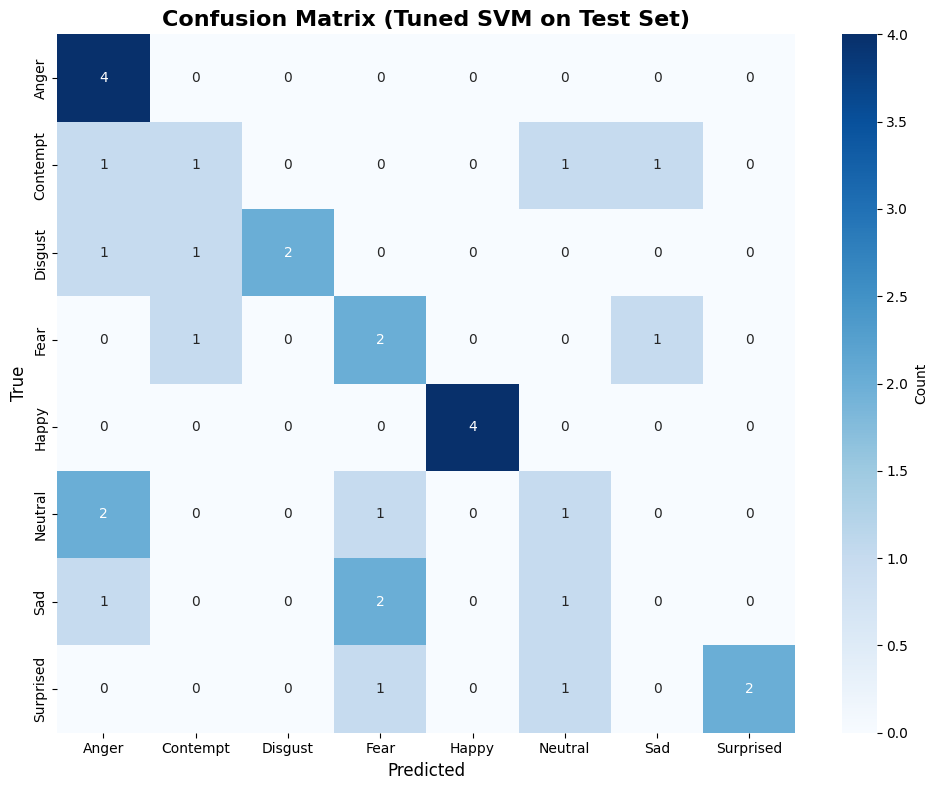

In [23]:
# Confusion matrix for tuned model
cm = confusion_matrix(y_test, y_test_pred_tuned)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes, cbar_kws={'label': 'Count'})
plt.title("Confusion Matrix (Tuned SVM on Test Set)", fontsize=16, fontweight='bold')
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("True", fontsize=12)
plt.tight_layout()
plt.show()

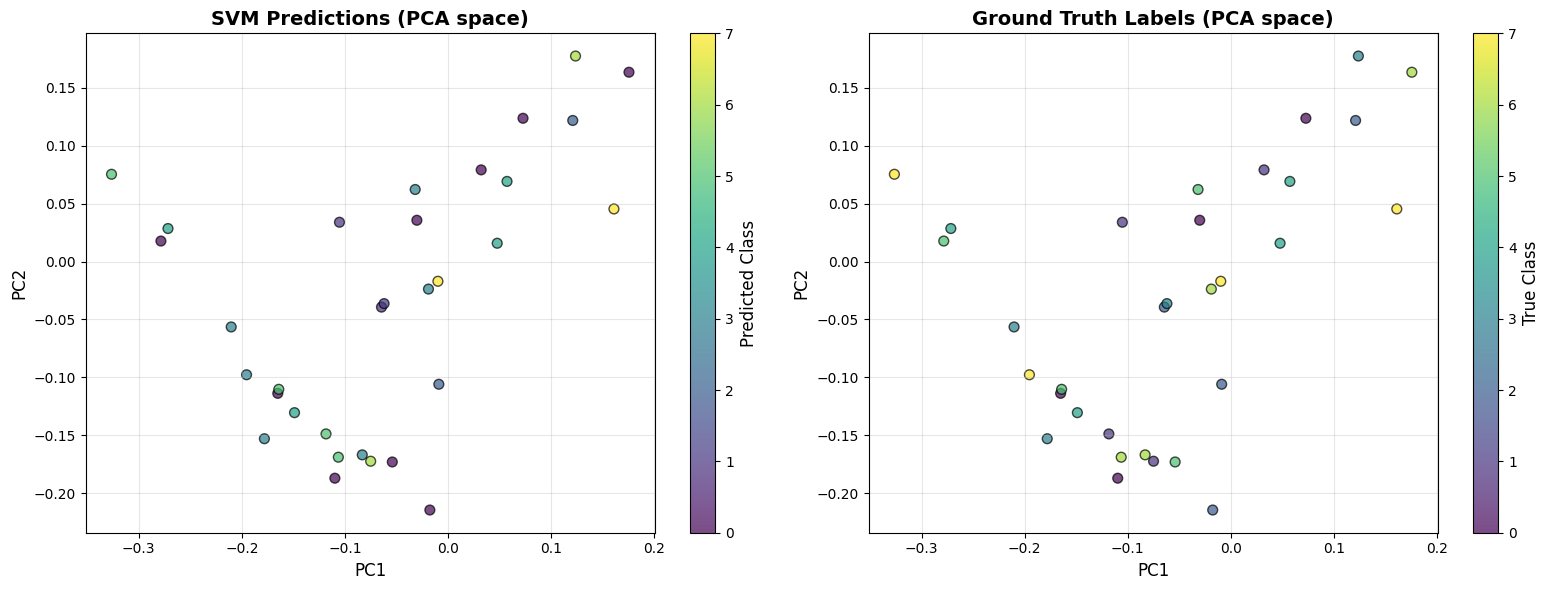

In [24]:
# Visualize test predictions in PCA-reduced space (first 2 components)
X_test_pca = best_svm.named_steps["pca"].transform(X_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Predictions
scatter1 = ax1.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test_pred_tuned, 
                       cmap='viridis', alpha=0.7, edgecolors='k', s=50)
ax1.set_title('SVM Predictions (PCA space)', fontsize=14, fontweight='bold')
ax1.set_xlabel("PC1", fontsize=12)
ax1.set_ylabel("PC2", fontsize=12)
cbar1 = plt.colorbar(scatter1, ax=ax1, ticks=range(len(classes)))
cbar1.set_label('Predicted Class', fontsize=12)
ax1.grid(alpha=0.3)

# Plot 2: Ground truth
scatter2 = ax2.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, 
                       cmap='viridis', alpha=0.7, edgecolors='k', s=50)
ax2.set_title('Ground Truth Labels (PCA space)', fontsize=14, fontweight='bold')
ax2.set_xlabel("PC1", fontsize=12)
ax2.set_ylabel("PC2", fontsize=12)
cbar2 = plt.colorbar(scatter2, ax=ax2, ticks=range(len(classes)))
cbar2.set_label('True Class', fontsize=12)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()